In [8]:
!pip install tensorflow

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers,models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import BatchNormalization
from sklearn.model_selection import train_test_split


In [3]:
df= pd.read_csv('C:\\Users\\PMLS\\Documents\\All Uni Work\\Data Science & AI\\skin_disease_data\\hmnist_28_28_RGB.csv')
X= df.drop('label', axis=1).values
y= df['label'].values

df.shape

(10015, 2353)

In [4]:
X = X.reshape(-1, 28, 28, 3) / 255.0


In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [6]:

X_train = X_train / 255.0
X_test = X_test / 255.0

datagen = ImageDataGenerator(
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
datagen.fit(X_train)


In [12]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(28,28,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128,(3,3),activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    # layers.BatchNormalization(),
    layers.Dense(128,activation='relu'),
    # layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(7, activation='softmax')
])


In [13]:
#learning rate adjustment
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
checkpoint = ModelCheckpoint('best_model.keras', monitor='val_loss', save_best_only=True)

optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003)

model.compile(optimizer=optimizer,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
            
model_prediction = model.fit(
    datagen.flow(X_train, y_train, batch_size=16),epochs=30,validation_data=(X_test, y_test),callbacks=[early_stop, checkpoint])

Epoch 1/30


c:\Users\PMLS\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


501/501 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - accuracy: 0.6499 - loss: 1.0297 - val_accuracy: 0.0464 - val_loss: 1.7516
Epoch 2/30
501/501 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.6922 - loss: 0.8693 - val_accuracy: 0.4528 - val_loss: 1.2208
Epoch 3/30
501/501 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.7057 - loss: 0.8212 - val_accuracy: 0.1208 - val_loss: 1.9053
Epoch 4/30
501/501 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.7134 - loss: 0.7907 - val_accuracy: 0.6690 - val_loss: 1.8221
Epoch 5/30
501/501 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.7260 - loss: 0.7681 - val_accuracy: 0.7354 - val_loss: 0.7492
Epoch 6/30
501/501 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.7335 - loss: 0.7330 - val_accuracy: 0.7169 - val_loss: 0.7364
Epoch 7/30
501/501 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.7379 - loss: 0.7144 - val_accuracy: 0.6635 - val_loss: 0.8792
Epoch 8/30
501/501 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.7438 - loss: 0.7100 - val_accuracy: 0.

In [14]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

print("Final Training Accuracy:", model_prediction.history['accuracy'][-1])

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7329 - loss: 0.7311
Test Accuracy: 0.7329006195068359
Test Loss: 0.7310830950737
Final Training Accuracy: 0.7666000723838806


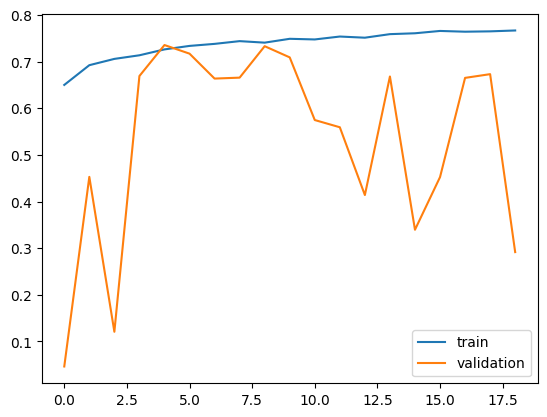

In [15]:
plt.plot(model_prediction.history['accuracy'], label='train')
plt.plot(model_prediction.history['val_accuracy'], label='validation')
plt.legend()
plt.show()